In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# Data Cleaning and Preprocessing

In [2]:
df = pd.read_csv('PS.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [5]:
df['type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 6362620 entries, 0 to 6362619
Series name: type
Non-Null Count    Dtype 
--------------    ----- 
6362620 non-null  object
dtypes: object(1)
memory usage: 48.5+ MB


In [6]:
df['type'].unique()

array(['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'],
      dtype=object)

In [7]:
# Remove duplicates
df.drop_duplicates(inplace=True)
print(f"After removing duplicates: {df.shape[0]:,} rows")

After removing duplicates: 6,362,620 rows


In [8]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Only remove outliers from non-fraud rows
    # Keep ALL fraud rows no matter what
    non_fraud = df[df['isFraud'] == 0]
    fraud = df[df['isFraud'] == 1]
    
    non_fraud_clean = non_fraud[
        (non_fraud[col] >= lower) & 
        (non_fraud[col] <= upper)
    ]
    
    return pd.concat([non_fraud_clean, fraud])

cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 
        'oldbalanceDest', 'newbalanceDest']

for col in cols:
    before = df.shape[0]
    df = remove_outliers(df, col)
    after = df.shape[0]
    print(f"{col}: removed {before - after:,} outliers")

print(f"\nTotal rows     : {df.shape[0]:,}")
print(f"Fraud remaining: {df['isFraud'].sum():,}")
print(f"Fraud %        : {df['isFraud'].mean()*100:.2f}%")

amount: removed 334,224 outliers
oldbalanceOrg: removed 1,058,130 outliers
newbalanceOrig: removed 925,062 outliers
oldbalanceDest: removed 535,955 outliers
newbalanceDest: removed 251,397 outliers

Total rows     : 3,257,852
Fraud remaining: 8,213
Fraud %        : 0.25%


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le = LabelEncoder()

In [11]:
df['type_encoded'] = le.fit_transform(df['type'])

In [12]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.00,0,0,3
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.00,0,0,3
5,1,PAYMENT,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.00,0,0,3
8,1,PAYMENT,4024.36,C1265012928,2671.0,0.00,M1176932104,0.0,0.00,0,0,3
9,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,2


In [13]:
df['type_encoded'].unique()

array([3, 2, 1, 4, 0])

In [14]:
df['nameOrig'].unique()

array(['C1666544295', 'C2048537720', 'C90045638', ..., 'C1162922333',
       'C1685995037', 'C1280323807'], dtype=object)

In [15]:
df_1 = df.drop(['type','nameOrig','nameDest'],axis = 'columns')

In [16]:
df_1.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded
1,1,1864.28,21249.0,19384.72,0.0,0.00,0,0,3
4,1,11668.14,41554.0,29885.86,0.0,0.00,0,0,3
5,1,7817.71,53860.0,46042.29,0.0,0.00,0,0,3
8,1,4024.36,2671.0,0.00,0.0,0.00,0,0,3
9,1,5337.77,41720.0,36382.23,41898.0,40348.79,0,0,2


In [17]:
df_1['step'].value_counts()

step
187    24917
235    24591
19     24455
18     23938
307    23897
       ...  
721        4
245        4
593        4
112        2
662        2
Name: count, Length: 743, dtype: int64

In [18]:
df_1.shape

(3257852, 9)

In [20]:
df_1.to_csv("output.csv", index=False)

# SQL DATABASE

In [21]:
import sqlite3
import csv

In [23]:
conn = sqlite3.connect('fraud_1.db')
cur = conn.cursor()

# Create table
cur.execute("""
    CREATE TABLE IF NOT EXISTS fraud_1(
        step INTEGER,
        amount REAl,
        oldbalanceOrg REAL,
        newbalanceOrig REAL,
        oldbalanceDest REAL,
        newbalanceDest REAL,
        isFraud INTEGER,
        isFlaggedFraud INTEGER,
        type_encoded INTEGER
    )
""")

In [24]:
with open('output.csv', 'r') as f:
    reader = csv.DictReader(f)
    rows = [(r['step'], r['amount'], 
             r['oldbalanceOrg'], r['newbalanceOrig'],
             r['oldbalanceDest'], r['newbalanceDest'],
             r['isFraud'], r['isFlaggedFraud'],r['type_encoded']) for r in reader]

cur.executemany("INSERT INTO fraud_1 VALUES (?,?,?,?,?,?,?,?,?)", rows)
conn.commit()

total = cur.execute("SELECT COUNT(*) FROM fraud_1").fetchone()[0]
print(f"Done! Total rows: {total:,}")

Done! Total rows: 3,257,852


In [25]:
total = cur.execute("SELECT COUNT(*) FROM fraud_1").fetchone()[0]
fraud = cur.execute("SELECT COUNT(*) FROM fraud_1 WHERE isFraud = 1").fetchone()[0]
not_fraud = cur.execute("SELECT COUNT(*) FROM fraud_1 WHERE isFraud = 0").fetchone()[0]

print(f"Total rows    : {total:,}")
print(f"Fraud rows    : {fraud:,}")
print(f"Not Fraud rows: {not_fraud:,}")
print(f"Fraud %       : {fraud/total*100:.2f}%")

Total rows    : 3,257,852
Fraud rows    : 8,213
Not Fraud rows: 3,249,639
Fraud %       : 0.25%


In [26]:
def query(sql):
    """Run any SQL and return rows + column names"""
    cur.execute(sql)
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description]
    return rows, cols

In [27]:
rows, cols = query("SELECT type_encoded, COUNT(*) as count FROM fraud_1 GROUP BY type_encoded")
print("Columns:", cols)
for row in rows:
    print(row)

Columns: ['type_encoded', 'count']
(0, 46136)
(1, 1373614)
(2, 22527)
(3, 1658475)
(4, 157100)


# EDA

# Target Variable Analysis

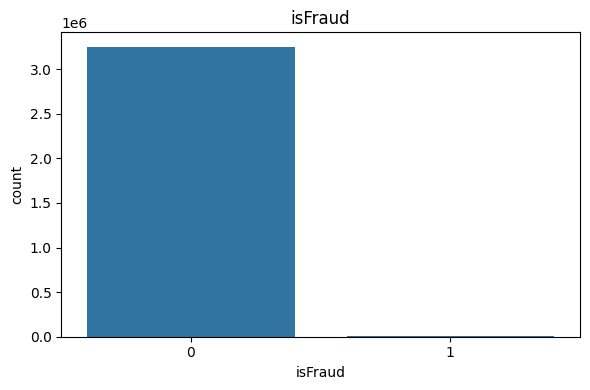

In [28]:
rows, _ = query("""
    SELECT isFraud, COUNT(*) as count
    FROM fraud_1
    GROUP BY isFraud
""")

labels = [r[0] for r in rows]
counts = [r[1] for r in rows]

plt.figure(figsize=(6, 4))
sn.barplot(x=labels, y=counts)
plt.title('isFraud')
plt.xlabel('isFraud')
plt.ylabel('count')
plt.tight_layout()
plt.show()

# Univariate Analysis

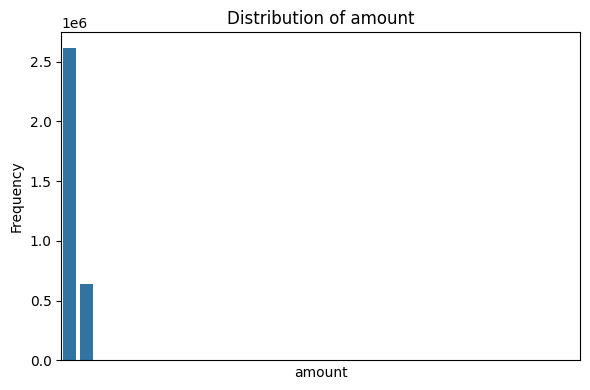

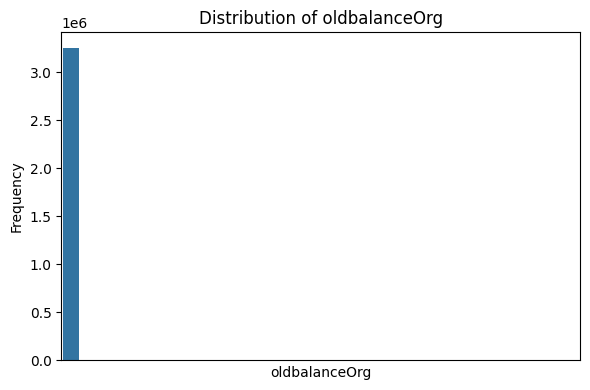

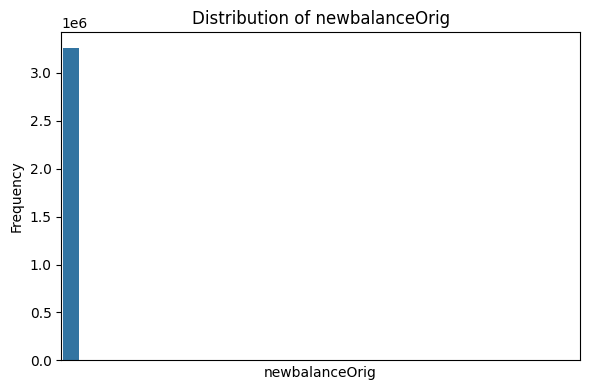

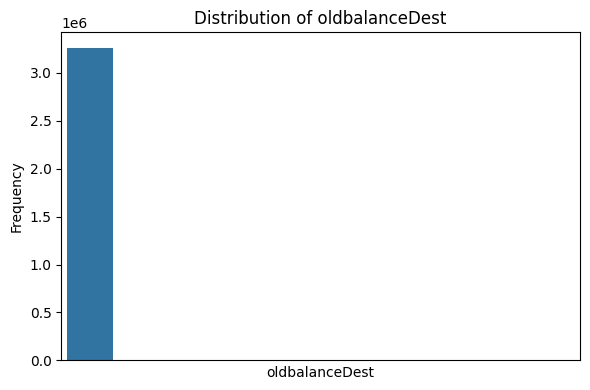

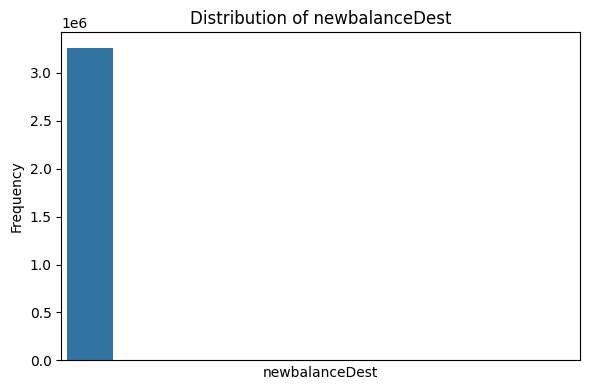

In [29]:
columns = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

def hist(CL):
    rows, _ = query(f"""
        SELECT 
            ROUND({CL} / (SELECT (MAX({CL}) - MIN({CL})) / 30.0 FROM fraud_1)) as bin,
            COUNT(*) as frequency
        FROM fraud_1
        GROUP BY bin
        ORDER BY bin
    """)
    
    bins   = [r[0] for r in rows]
    counts = [r[1] for r in rows]
    
    plt.figure(figsize=(6, 4))
    sn.barplot(x=bins, y=counts)
    plt.title(f"Distribution of {CL}")
    plt.xlabel(CL)
    plt.ylabel("Frequency")
    plt.xticks([])   # bin numbers are not meaningful on x axis
    plt.tight_layout()
    plt.show()

for col in columns:
    hist(col)

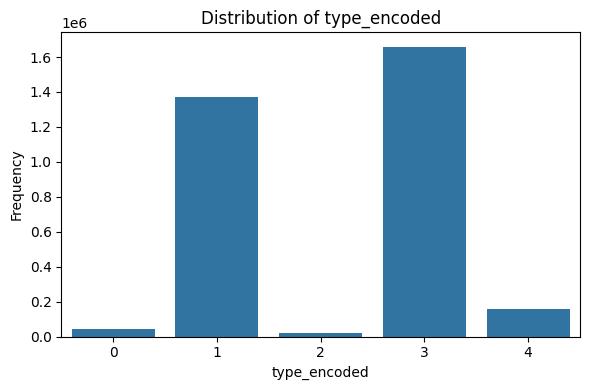

In [30]:
rows, _ = query("""
    SELECT type_encoded, COUNT(*) as count
    FROM fraud_1
    GROUP BY type_encoded
    ORDER BY type_encoded
""")

labels = [r[0] for r in rows]
counts = [r[1] for r in rows]

plt.figure(figsize=(6, 4))
sn.barplot(x=labels, y=counts)
plt.xlabel('type_encoded')
plt.ylabel('Frequency')
plt.title('Distribution of type_encoded')
plt.tight_layout()
plt.show()

# Bivariate Analysis

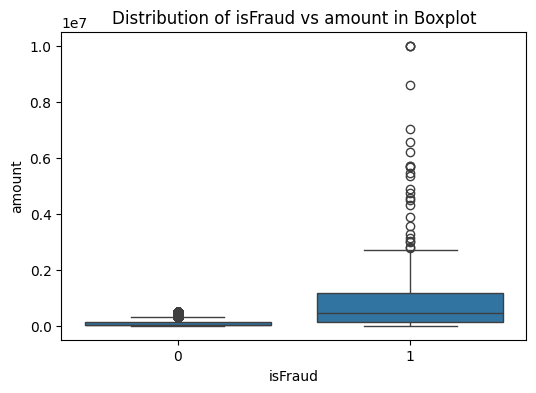

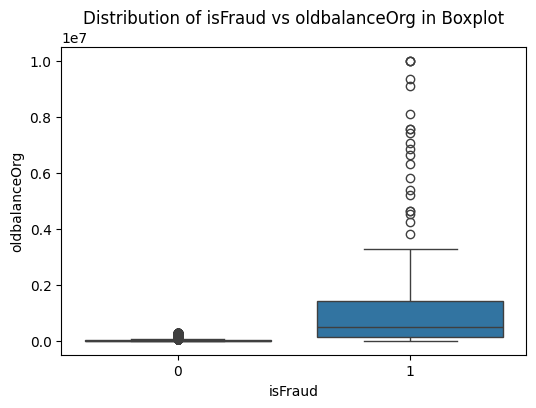

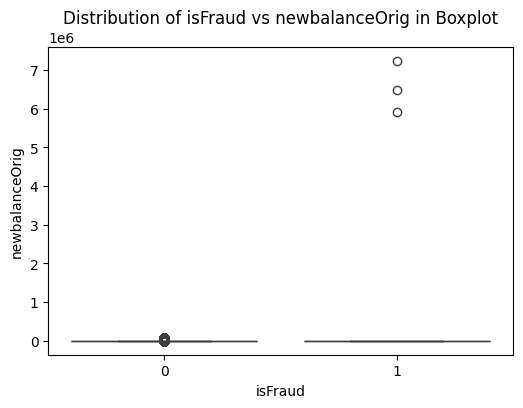

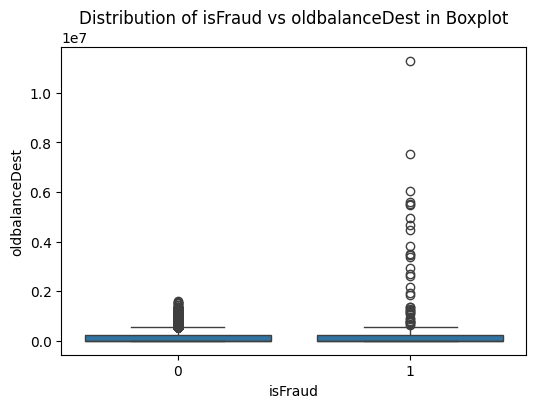

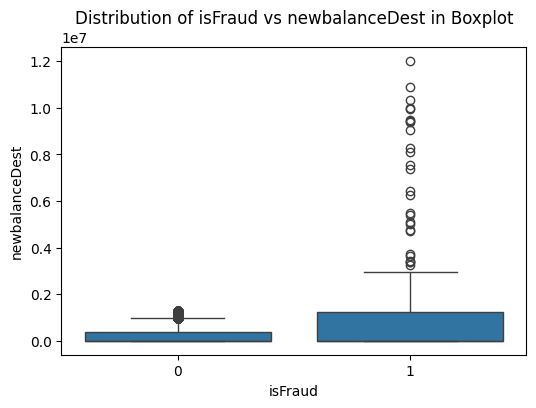

In [31]:
Dl = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

def bivarate_box(Dl):
    rows, _ = query(f"SELECT isFraud, {Dl} FROM fraud_1 ORDER BY RANDOM() LIMIT 60000")
    
    import pandas as pd
    df_sample = pd.DataFrame({'isFraud': [r[0] for r in rows], Dl: [r[1] for r in rows]})
    
    plt.figure(figsize=(6, 4))
    sn.boxplot(x='isFraud', y=Dl, data=df_sample)
    plt.title(f"Distribution of isFraud vs {Dl} in Boxplot")
    plt.xlabel('isFraud')
    plt.ylabel(Dl)
    plt.show()

for col in Dl:
    bivarate_box(col)

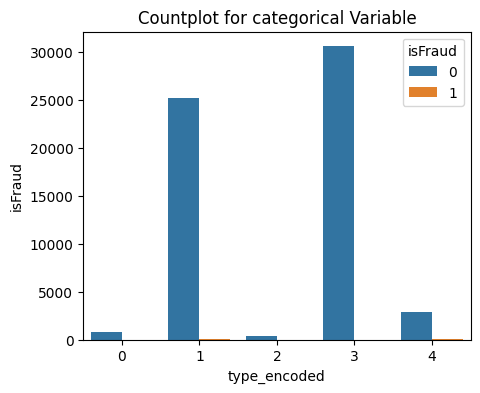

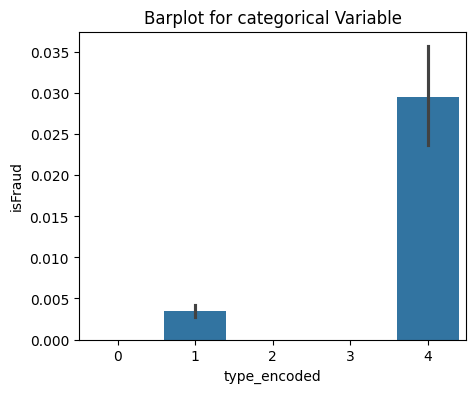

In [32]:
# Countplot + Barplot
rows, _ = query("""
    SELECT type_encoded, isFraud
    FROM fraud_1
    ORDER BY RANDOM()
    LIMIT 60000
""")

import pandas as pd
df_sample = pd.DataFrame(rows, columns=['type_encoded', 'isFraud'])

plt.figure(figsize=(5, 4))
sn.countplot(x='type_encoded', hue='isFraud', data=df_sample)
plt.xlabel('type_encoded')
plt.ylabel('isFraud')
plt.title('Countplot for categorical Variable')
plt.show()

plt.figure(figsize=(5, 4))
sn.barplot(x='type_encoded', y='isFraud', data=df_sample)
plt.xlabel('type_encoded')
plt.ylabel('isFraud')
plt.title('Barplot for categorical Variable')
plt.show()

# correlation Analysis 

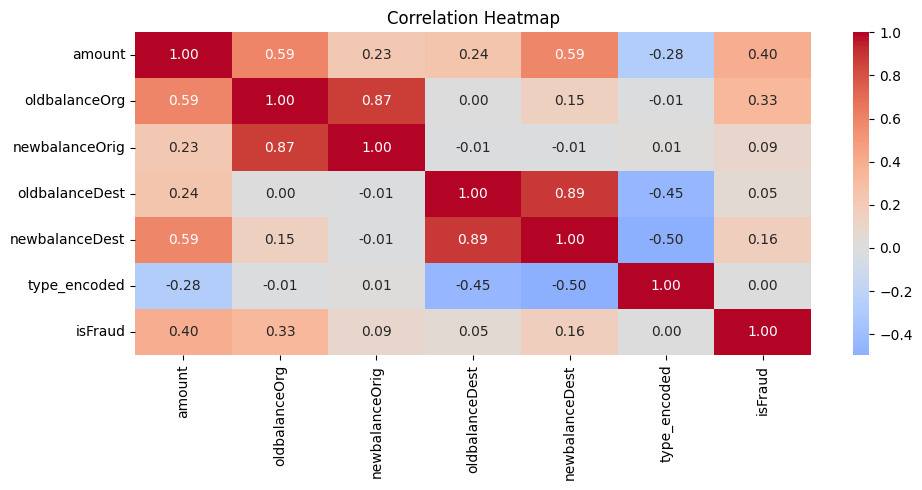

In [33]:
rows, _ = query("""
    SELECT 
        amount, oldbalanceOrg, newbalanceOrig,
        oldbalanceDest, newbalanceDest,
        type_encoded, isFraud
    FROM fraud_1
    ORDER BY RANDOM()
    LIMIT 60000
""")

import pandas as pd
df_sample = pd.DataFrame(rows, columns=['amount', 'oldbalanceOrg', 'newbalanceOrig',
                                         'oldbalanceDest', 'newbalanceDest',
                                         'type_encoded', 'isFraud'])

Corr = df_sample.corr()

plt.figure(figsize=(10, 5))
sn.heatmap(Corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Model Spliting 

In [34]:
from sklearn.model_selection import train_test_split
X = df_1.drop(['isFraud'] , axis =1)
y = df_1.isFraud

In [35]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,type_encoded
1,1,1864.28,21249.0,19384.72,0.0,0.00,0,3
4,1,11668.14,41554.0,29885.86,0.0,0.00,0,3
5,1,7817.71,53860.0,46042.29,0.0,0.00,0,3
8,1,4024.36,2671.0,0.00,0.0,0.00,0,3
9,1,5337.77,41720.0,36382.23,41898.0,40348.79,0,2


In [36]:
y.head()

1    0
4    0
5    0
8    0
9    0
Name: isFraud, dtype: int64

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [38]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((2606281, 8), (651571, 8), (2606281,), (651571,))

# Hyperparameter Tunning


In [39]:
from lightgbm import LGBMClassifier as lgb
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [40]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg/pos


def objective(trial):
    classifier_name = trial.suggest_categorical(
        "classifier",
        ["lgb", "xgb"]
    )
    if classifier_name == "lgb":
        model = lgb(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            num_leaves=trial.suggest_int("num_leaves", 20, 80),
            max_depth=trial.suggest_int("max_depth", 4, 12),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
            device="gpu",
            verbosity=-1
        )
    else:
        model = XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),
            max_depth=trial.suggest_int("max_depth", 4, 12),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
            scale_pos_weight=scale_pos_weight,  # handles class imbalance
            device="cuda",             # GPU support
            random_state=42
        )
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=2,
        scoring="accuracy"
    ).mean()
    return score

In [41]:
import optuna
study = optuna.create_study(direction = 'maximize')
study.optimize(objective,n_trials = 10)

[I 2026-06-05 18:06:37,827] A new study created in memory with name: no-name-ac34faf1-369d-4083-8b39-2d7ab9f8df5c
C:\Users\Rahul\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:751: UserWarning: [18:06:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-06-05 18:06:58,575] Trial 0 finished with value: 0.9994632198150106 and parameters: {'classifier': 'xgb', 'n_estimators': 343, 'max_depth': 10, 'learning_rate': 0.10940890568865992, 'subsample': 0.8238241464253744, 'colsample_bytree': 0.784226004171437}. Best is trial 0 

In [44]:
study.best_params

{'classifier': 'lgb',
 'n_estimators': 341,
 'num_leaves': 59,
 'max_depth': 9,
 'learning_rate': 0.021457326247698652,
 'subsample': 0.8616824442747353,
 'colsample_bytree': 0.809512514529943}

In [47]:
study.best_value

0.9995648972601814

# Training with the best Model

In [51]:
values = study.best_params

model = lgb(
    n_estimators = values['n_estimators'],
    learning_rate = values['learning_rate'],
    max_depth = values['max_depth'],
    num_leaves= values['num_leaves'],
    subsample = values['subsample'],
    colsample_bytree = values['colsample_bytree'],
    n_jobs=-1,
    device="gpu"
)

In [52]:
model.fit(X_train,y_train)

,boosting_type,'gbdt'
,num_leaves,59
,max_depth,9
,learning_rate,0.021457326247698652
,n_estimators,341
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [53]:
model.score(X_train,y_train)

0.9997241279815953

In [54]:
model.score(X_test,y_test)

0.9995810126601705

# Evaluation 

# Confusion matrix and Classification Report

In [56]:
y_pred_model = model.predict(X_test)
from sklearn.metrics import confusion_matrix , classification_report 

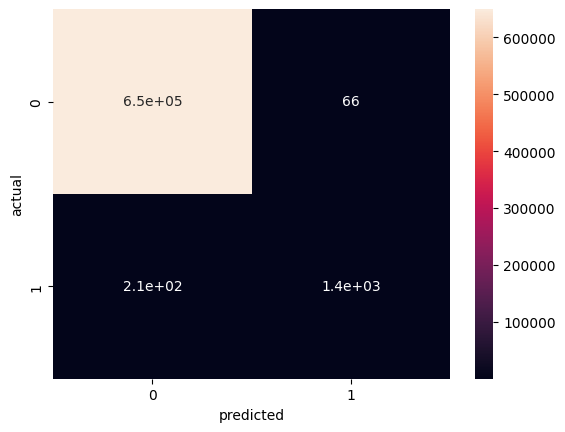

In [60]:
cm_model  = confusion_matrix(y_test,y_pred_model )
sn.heatmap(cm_model,annot = True)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()


In [62]:
report = classification_report(y_test,y_pred_model)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    649925
           1       0.96      0.87      0.91      1646

    accuracy                           1.00    651571
   macro avg       0.98      0.94      0.96    651571
weighted avg       1.00      1.00      1.00    651571



# ROC_CURE & AUC Score

In [63]:
from sklearn.metrics import roc_curve , roc_auc_score

In [64]:
def roc(Model):
    y_prob = Model.predict_proba(X_test)[:,1]
    fpr,tpr,_ = roc_curve(y_test,y_prob)
    plt.plot(fpr,tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()
    print("auc_score is",roc_auc_score(y_test,y_prob))

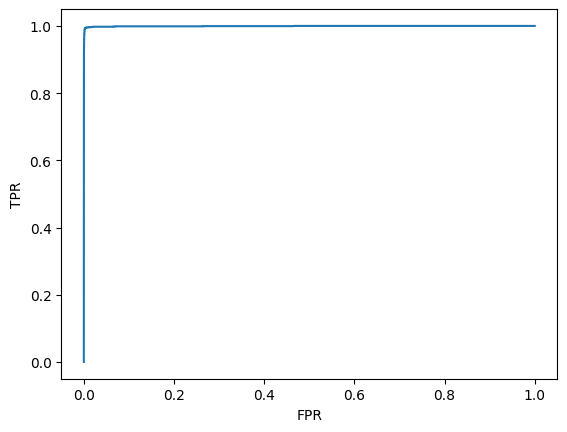

auc_score is 0.9993572564289244


In [65]:
roc(model)

# PRC Curve

In [66]:
from sklearn.metrics import precision_recall_curve as prc

def Prc(Model):
    y_prob = Model.predict_proba(X_test)[:,1]
    precision,recall,thrashold = prc(y_test,y_prob)
    plt.plot(recall,precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()

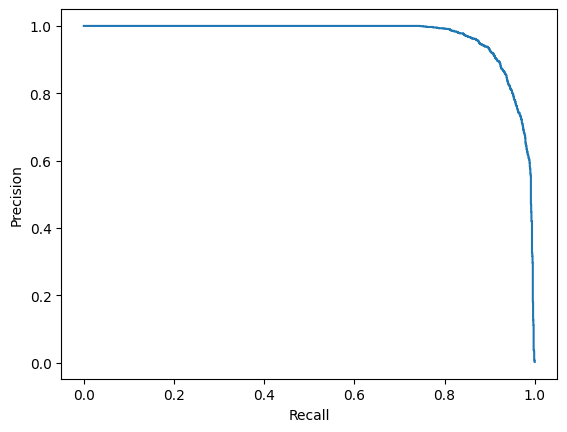

In [67]:
Prc(model)

# Model saving

In [70]:
import pickle


lgb_Classifier = 'lgb_classifier.pkl'
with open(lgb_Classifier,'wb') as F2:
    pickle.dump(model,F2)